In [1]:
import wecgrid
setup = wecgrid.Engine() 
setup.database.set_database_path('../examples/WECGrid.db')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
import wecgrid
osmses = wecgrid.Engine()
#osmses.case("../examples/grid_models/IEEE_300_bus.RAW")
osmses.case("../examples/grid_models/IEEE_14_bus.RAW")
osmses.load(["pypsa"])

In [ ]:
osmses.plot.sld()

ValueError: No bus data available for SLD generation

In [ ]:
# for i in range(1,20):
#     if i != 18:
#         osmses.apply_wec(
#         farm_name = f"WEC-Farm-RM3-{i}",
#         size = 100, # ten RM3 in WEC farm  
#         wec_sim_id = 1, # RM3 run id  
#         bus_location=700+i, # create a new bus for farm  
#         connecting_bus = i, # Connect to bus 1 or swing bus
#     )

In [ ]:
osmses.pypsa.network

PyPSA Network
Components:
 - Bus: 14
 - Generator: 5
 - Line: 17
 - Load: 11
 - SubNetwork: 1
 - Transformer: 3
Snapshots: 1

In [ ]:
osmses.simulate() # takes some time!
osmses.pypsa.report

PyPSA Simulating: 100%|██████████| 288/288 [00:59<00:00,  4.88step/s]


SolveReport: Successful, steps=288, time=59.05s, case=IEEE 14 bus, sw=pypsa

In [ ]:
osmses.plot.bus(software="pypsa", parameter="v_mag", bus=["Bus_701"])

(None, None)

In [ ]:
# Check grid health metrics after simulation
osmses.pypsa.health

GridHealthMetrics (288 timesteps):
├─ Status: ⚠ Issues Detected
├─ Thermal Stress:
│   ├─ Max Line Loading: nan%
│   └─ Time Above 90%: 0.0%
├─ Voltage Security:
│   ├─ Violations: 1152 (under: 0, over: 1152)
│   ├─ Voltage Range: [1.0100, 1.0900] pu
│   └─ Min Margin: -0.0400 pu
├─ Reactive Adequacy:
│   ├─ Max Q Loading: 312.6%
│   └─ Time Q-Limited: 100.0%
├─ Inertia Proxy:
│   ├─ Min Sync Gen Share: 100.0%
│   └─ Min System Inertia: 2398.9 MWs
└─ Convergence Failures: 0

In [ ]:
# Get the health metrics as a DataFrame for analysis
health_df = osmses.pypsa.health.dataframe
health_df.head(10)

,converged,line_loading_max,line_loading_mean,line_loading_std,num_lines_above_90_pct,num_lines_above_100_pct,line_warning_count,line_overload_count,v_min,v_max,...,any_gen_q_limited,total_q_generation_pu,total_generation_pu,gen_count_active,system_inertia_mws,sync_gen_share,total_online_capacity_mw,total_load_pu,power_balance_pu,is_healthy
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-09 00:00:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:05:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:10:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:15:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:20:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:25:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:30:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:35:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False
2025-12-09 00:40:00,True,NaN,NaN,NaN,0,0,0,0,1.01,1.09,...,True,1.292318,2.726,2,2398.87994,1.0,272.599993,2.59,0.136,False


In [ ]:
# Get aggregate summary statistics
osmses.pypsa.health.summary

{'overall_healthy': False,
 'total_timesteps': 288,
 'healthy_timesteps': 0,
 'unhealthy_timesteps': 288,
 'convergence_failures': 0,
 'worst_line_loading_pct': nan,
 'mean_line_loading_pct': nan,
 'frac_time_line_above_90': 0.0,
 'frac_time_line_above_100': 0.0,
 'total_line_overloads': 0,
 'total_line_warnings': 0,
 'worst_min_voltage': 1.01,
 'worst_max_voltage': 1.09,
 'worst_voltage_margin': -0.040000000000000036,
 'mean_voltage_margin': 0.008260476975000255,
 'frac_time_voltage_violation': 1.0,
 'total_voltage_violations': 1152,
 'total_undervoltage': 0,
 'total_overvoltage': 1152,
 'worst_q_loading': 3.125535288588404,
 'mean_q_loading': 2.0704946897009044,
 'frac_time_q_limited': 1.0,
 'total_q_limit_events': 1152,
 'min_sync_gen_share': 1.0,
 'mean_sync_gen_share': 1.0,
 'min_system_inertia': 2398.879939766721,
 'mean_system_inertia': 2398.879939766721,
 'min_voltage_pu': 1.01,
 'max_voltage_pu': 1.09,
 'max_line_loading_pct': nan,
 'top_5_stressed_lines': [{'line': 'Line_1',


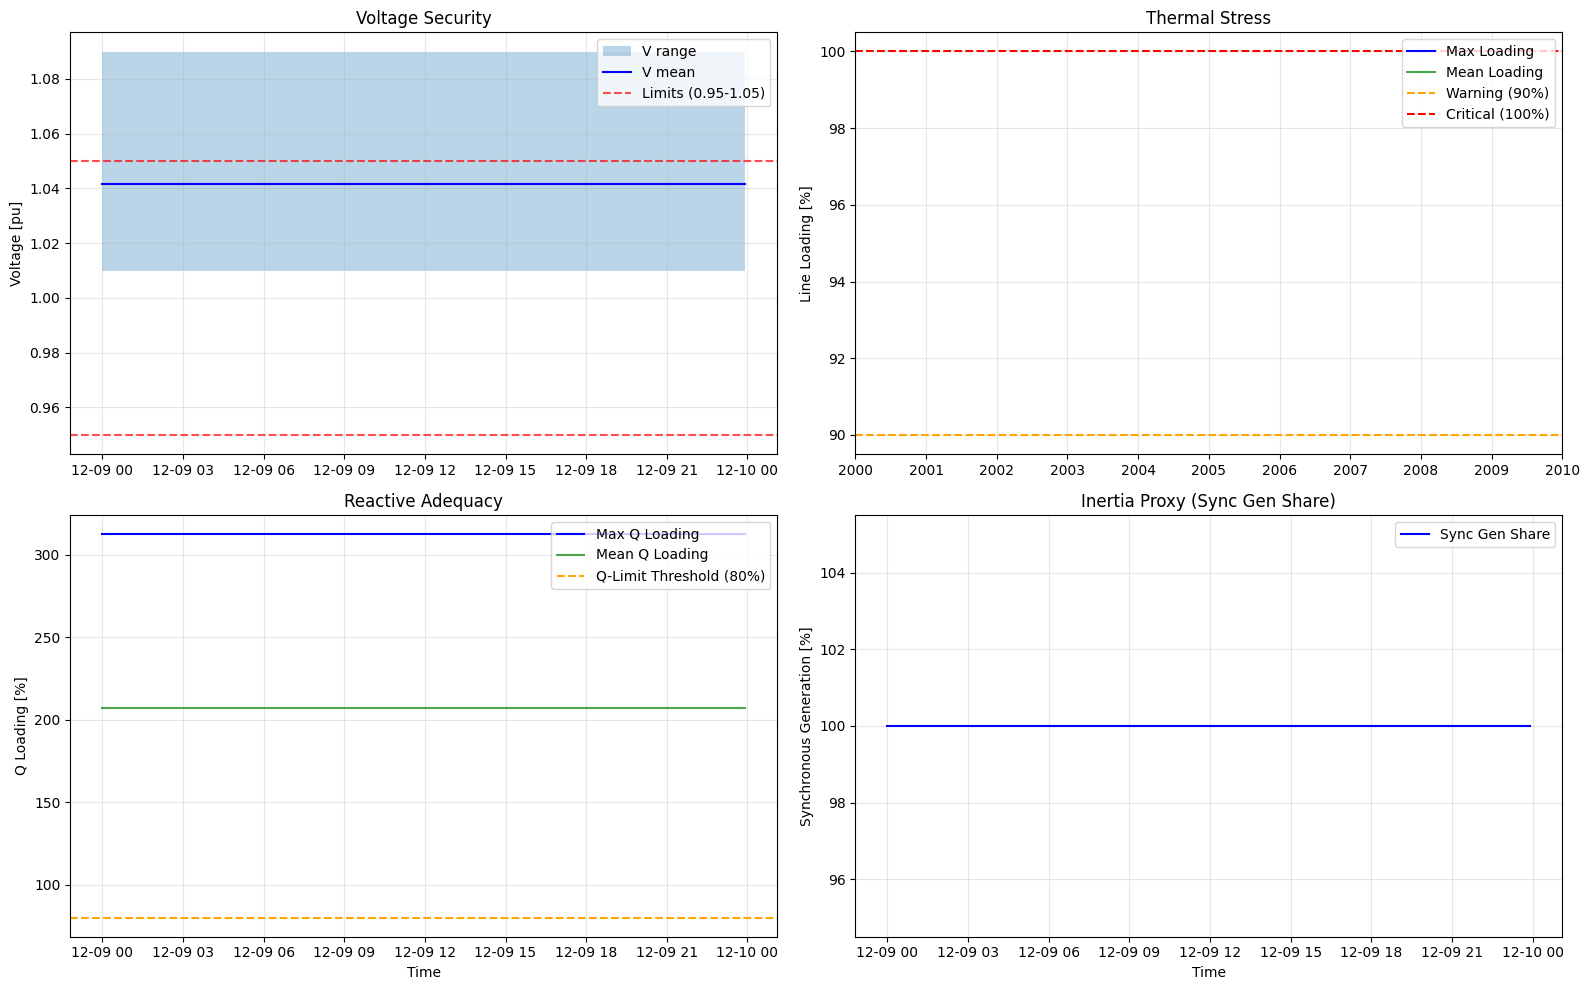

In [ ]:
# Plot comprehensive grid health dashboard
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Voltage Profile with Margin
voltage_profile = osmses.pypsa.health.voltage_profile()
ax1 = axes[0, 0]
ax1.fill_between(voltage_profile.index, voltage_profile['v_min'], voltage_profile['v_max'], alpha=0.3, label='V range')
ax1.plot(voltage_profile.index, voltage_profile['v_mean'], 'b-', label='V mean')
ax1.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='Limits (0.95-1.05)')
ax1.axhline(y=1.05, color='r', linestyle='--', alpha=0.7)
ax1.set_ylabel('Voltage [pu]')
ax1.set_title('Voltage Security')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Line Loading (Thermal Stress)
line_profile = osmses.pypsa.health.line_loading_profile()
ax2 = axes[0, 1]
ax2.plot(line_profile.index, line_profile['line_loading_max'], 'b-', label='Max Loading')
ax2.plot(line_profile.index, line_profile['line_loading_mean'], 'g-', alpha=0.7, label='Mean Loading')
ax2.axhline(y=90, color='orange', linestyle='--', label='Warning (90%)')
ax2.axhline(y=100, color='r', linestyle='--', label='Critical (100%)')
ax2.set_ylabel('Line Loading [%]')
ax2.set_title('Thermal Stress')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. Reactive Adequacy (Q-loading)
reactive_profile = osmses.pypsa.health.reactive_profile()
ax3 = axes[1, 0]
if 'max_q_loading' in reactive_profile.columns:
    ax3.plot(reactive_profile.index, reactive_profile['max_q_loading'] * 100, 'b-', label='Max Q Loading')
    ax3.plot(reactive_profile.index, reactive_profile['mean_q_loading'] * 100, 'g-', alpha=0.7, label='Mean Q Loading')
    ax3.axhline(y=80, color='orange', linestyle='--', label='Q-Limit Threshold (80%)')
ax3.set_ylabel('Q Loading [%]')
ax3.set_xlabel('Time')
ax3.set_title('Reactive Adequacy')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# 4. Inertia / Synchronous Generation Share
inertia_profile = osmses.pypsa.health.inertia_profile()
ax4 = axes[1, 1]
if 'sync_gen_share' in inertia_profile.columns:
    ax4.plot(inertia_profile.index, inertia_profile['sync_gen_share'] * 100, 'b-', label='Sync Gen Share')
    ax4.set_ylabel('Synchronous Generation [%]')
ax4.set_xlabel('Time')
ax4.set_title('Inertia Proxy (Sync Gen Share)')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Get top 5 most stressed components
print("=" * 60)
print("TOP 5 MOST STRESSED LINES (Thermal)")
print("=" * 60)
for i, line in enumerate(osmses.pypsa.health.summary['top_5_stressed_lines'], 1):
    print(f"{i}. {line['line']}: max={line['max_loading_pct']:.1f}%, mean={line['mean_loading_pct']:.1f}%, time>90%={line['frac_time_above_90']*100:.1f}%")

print("\n" + "=" * 60)
print("TOP 5 VOLTAGE-STRESSED BUSES")
print("=" * 60)
for i, bus in enumerate(osmses.pypsa.health.summary['top_5_voltage_stressed_buses'], 1):
    print(f"{i}. {bus['bus']}: V=[{bus['min_voltage_pu']:.4f}, {bus['max_voltage_pu']:.4f}], margin={bus['min_margin_pu']:.4f}, violations={bus['frac_time_violation']*100:.1f}%")

print("\n" + "=" * 60)
print("TOP 5 Q-STRESSED GENERATORS")
print("=" * 60)
for i, gen in enumerate(osmses.pypsa.health.summary['top_5_q_stressed_gens'], 1):
    print(f"{i}. {gen['generator']}: max_Q={gen['max_q_loading']*100:.1f}%, mean_Q={gen['mean_q_loading']*100:.1f}%, time_limited={gen['frac_time_q_limited']*100:.1f}%")

TOP 5 MOST STRESSED LINES (Thermal)
1. Line_1: max=0.0%, mean=0.0%, time>90%=0.0%
2. Line_2: max=0.0%, mean=0.0%, time>90%=0.0%
3. Line_3: max=0.0%, mean=0.0%, time>90%=0.0%
4. Line_4: max=0.0%, mean=0.0%, time>90%=0.0%
5. Line_5: max=0.0%, mean=0.0%, time>90%=0.0%

TOP 5 VOLTAGE-STRESSED BUSES
1. Bus_8: V=[1.0900, 1.0900], margin=-0.0400, violations=100.0%
2. Bus_6: V=[1.0700, 1.0700], margin=-0.0200, violations=100.0%
3. Bus_1: V=[1.0600, 1.0600], margin=-0.0100, violations=100.0%
4. Bus_12: V=[1.0534, 1.0534], margin=-0.0034, violations=100.0%
5. Bus_7: V=[1.0494, 1.0494], margin=0.0006, violations=0.0%

TOP 5 Q-STRESSED GENERATORS
1. Gen_3: max_Q=312.6%, mean_Q=312.6%, time_limited=100.0%
2. Gen_5: max_Q=251.1%, mean_Q=251.1%, time_limited=100.0%
3. Gen_2: max_Q=234.3%, mean_Q=234.3%, time_limited=100.0%
4. Gen_4: max_Q=230.0%, mean_Q=230.0%, time_limited=100.0%
5. Gen_1: max_Q=7.2%, mean_Q=7.2%, time_limited=0.0%


In [ ]:
# Print comprehensive summary statistics
summary = osmses.pypsa.health.summary
print("=" * 70)
print("GRID HEALTH SUMMARY - IEEE 300 Bus + 19 WEC Farms")
print("=" * 70)

print(f"\n{'OVERALL':^70}")
print("-" * 70)
print(f"  Total Timesteps: {summary['total_timesteps']}")
print(f"  Healthy Timesteps: {summary['healthy_timesteps']} ({summary['healthy_timesteps']/summary['total_timesteps']*100:.1f}%)")
print(f"  Convergence Failures: {summary['convergence_failures']}")

print(f"\n{'THERMAL STRESS':^70}")
print("-" * 70)
print(f"  Worst Line Loading: {summary['worst_line_loading_pct']:.1f}%")
print(f"  Mean Line Loading: {summary['mean_line_loading_pct']:.1f}%")
print(f"  Time with Lines > 90%: {summary['frac_time_line_above_90']*100:.1f}%")
print(f"  Time with Lines > 100%: {summary['frac_time_line_above_100']*100:.1f}%")

print(f"\n{'VOLTAGE SECURITY':^70}")
print("-" * 70)
print(f"  Voltage Range: [{summary['worst_min_voltage']:.4f}, {summary['worst_max_voltage']:.4f}] pu")
print(f"  Worst Voltage Margin: {summary['worst_voltage_margin']:.4f} pu")
print(f"  Mean Voltage Margin: {summary['mean_voltage_margin']:.4f} pu")
print(f"  Time with Voltage Violations: {summary['frac_time_voltage_violation']*100:.1f}%")
print(f"  Total Undervoltage Events: {summary['total_undervoltage']}")
print(f"  Total Overvoltage Events: {summary['total_overvoltage']}")

print(f"\n{'REACTIVE ADEQUACY':^70}")
print("-" * 70)
print(f"  Worst Q Loading: {summary['worst_q_loading']*100:.1f}%")
print(f"  Mean Q Loading: {summary['mean_q_loading']*100:.1f}%")
print(f"  Time with Generators Q-Limited: {summary['frac_time_q_limited']*100:.1f}%")

print(f"\n{'INERTIA PROXY':^70}")
print("-" * 70)
print(f"  Min Synchronous Gen Share: {summary['min_sync_gen_share']*100:.1f}%")
print(f"  Mean Synchronous Gen Share: {summary['mean_sync_gen_share']*100:.1f}%")
print(f"  Min System Inertia: {summary['min_system_inertia']:.1f} MWs")
print(f"  Mean System Inertia: {summary['mean_system_inertia']:.1f} MWs")
print("=" * 70)

GRID HEALTH SUMMARY - IEEE 300 Bus + 19 WEC Farms

                               OVERALL                                
----------------------------------------------------------------------
  Total Timesteps: 288
  Healthy Timesteps: 0 (0.0%)
  Convergence Failures: 0

                            THERMAL STRESS                            
----------------------------------------------------------------------
  Worst Line Loading: nan%
  Mean Line Loading: nan%
  Time with Lines > 90%: 0.0%
  Time with Lines > 100%: 0.0%

                           VOLTAGE SECURITY                           
----------------------------------------------------------------------
  Voltage Range: [1.0100, 1.0900] pu
  Worst Voltage Margin: -0.0400 pu
  Mean Voltage Margin: 0.0083 pu
  Time with Voltage Violations: 100.0%
  Total Undervoltage Events: 0
  Total Overvoltage Events: 1152

                          REACTIVE ADEQUACY                           
------------------------------------------------

In [ ]:
# Export all health data for further analysis
health_df = osmses.pypsa.health.dataframe

# Save to CSV
# health_df.to_csv('ieee300_wec_integration_health_metrics.csv')

# Display key columns
health_df[['line_loading_max', 'num_lines_above_90_pct', 'v_min', 'v_max', 
           'min_voltage_margin', 'voltage_violation_count', 'max_q_loading', 
           'sync_gen_share', 'is_healthy']].describe()

,line_loading_max,num_lines_above_90_pct,v_min,v_max,min_voltage_margin,voltage_violation_count,max_q_loading,sync_gen_share
count,0.0,288.0,288.00,288.00,288.00,288.0,288.000000,288.0
mean,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0
std,NaN,0.0,0.00,0.00,0.00,0.0,0.000000,0.0
min,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0
25%,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0
50%,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0
75%,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0
max,NaN,0.0,1.01,1.09,-0.04,4.0,3.125535,1.0


In [ ]:
osmses.pypsa.network.lopf()

ApplicationError: No executable found for solver 'glpk'